# 01 — EDA: PhysioNet Challenge 2019 Sepsis

Mục tiêu:
1. Hiểu shape + missingness của dataset.
2. Verify class imbalance (~2% sepsis).
3. Visualize distribution vitals theo nhóm sepsis vs non-sepsis (để báo cáo).
4. Check temporal pattern: sepsis xuất hiện ở giờ nào trong ICU stay?

Notebook chỉ import + plot. Logic load/feature ở `ml/src/preprocess.py`.

In [1]:
import sys
from pathlib import Path

# Add project root vào sys.path (notebook nằm trong ml/notebooks/)
PROJECT_ROOT = Path.cwd().resolve().parents[1]
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

import logging
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

from ml.src.preprocess import (
    DEMO_COLS,
    LAB_COLS,
    TARGET_COL,
    VITAL_COLS,
    load_psv_files,
)

logging.basicConfig(level=logging.INFO, format="%(asctime)s %(levelname)s %(message)s")
sns.set_theme(style="whitegrid")
pd.options.display.max_columns = 50
print(f"Project root: {PROJECT_ROOT}")

Project root: D:\S2_Year4\Emerging Technologies\Project


## 1. Load data

Để EDA nhanh, dùng `max_patients=2000` (~1000 mỗi hospital). Để load full 40k chỉ cần xóa arg.

In [2]:
data_dirs = [
    PROJECT_ROOT / "ml" / "data" / "training_setA",
    PROJECT_ROOT / "ml" / "data" / "training_setB",
]

df = load_psv_files(data_dirs, max_patients=2000)
print(f"Shape: {df.shape}")
print(f"Patients: {df['patient_id'].nunique()}")
print(f"Rows per patient (avg): {len(df) / df['patient_id'].nunique():.1f}")
df.head()

2026-05-11 21:46:28,901 INFO Loading 2000 PSV files from 2 dirs
2026-05-11 21:46:36,211 INFO Loaded shape=(78083, 42), patients=2000


Shape: (78083, 42)
Patients: 2000
Rows per patient (avg): 39.0


,HR,O2Sat,Temp,SBP,MAP,DBP,Resp,EtCO2,BaseExcess,HCO3,FiO2,pH,PaCO2,SaO2,AST,BUN,Alkalinephos,Calcium,Chloride,Creatinine,Bilirubin_direct,Glucose,Lactate,Magnesium,Phosphate,Potassium,Bilirubin_total,TroponinI,Hct,Hgb,PTT,WBC,Fibrinogen,Platelets,Age,Gender,Unit1,Unit2,HospAdmTime,ICULOS,SepsisLabel,patient_id
0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,83.14,0,NaN,NaN,-0.03,1,0,p000001
1,97.0,95.0,NaN,98.0,75.33,NaN,19.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,83.14,0,NaN,NaN,-0.03,2,0,p000001
2,89.0,99.0,NaN,122.0,86.00,NaN,22.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,83.14,0,NaN,NaN,-0.03,3,0,p000001
3,90.0,95.0,NaN,NaN,NaN,NaN,30.0,NaN,24.0,NaN,NaN,7.36,100.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,83.14,0,NaN,NaN,-0.03,4,0,p000001
4,103.0,88.5,NaN,122.0,91.33,NaN,24.5,NaN,NaN,NaN,0.28,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,83.14,0,NaN,NaN,-0.03,5,0,p000001


## 2. Class imbalance

Sepsis là rare positive. Đo cả 2 góc: per-row và per-patient.

In [3]:
row_rate = df[TARGET_COL].mean()
patient_rate = df.groupby("patient_id")[TARGET_COL].max().mean()
print(f"Per-row sepsis rate:     {row_rate:.4f} ({row_rate*100:.2f}%)")
print(f"Per-patient sepsis rate: {patient_rate:.4f} ({patient_rate*100:.2f}%)")

# Vì sao per-patient cao hơn: 1 patient sepsis chỉ có ~10-20% giờ là label=1
# (label đặt sớm 6h trước onset → sau onset không còn label=1).

Per-row sepsis rate:     0.0225 (2.25%)
Per-patient sepsis rate: 0.0920 (9.20%)


## 3. Missingness heatmap

Lab values sample thưa (mỗi 6-24h) → NaN nhiều. Vital signs đo mỗi giờ → ít NaN.
Pattern này biện minh cho strategy: rolling cho vitals, ffill cho labs.

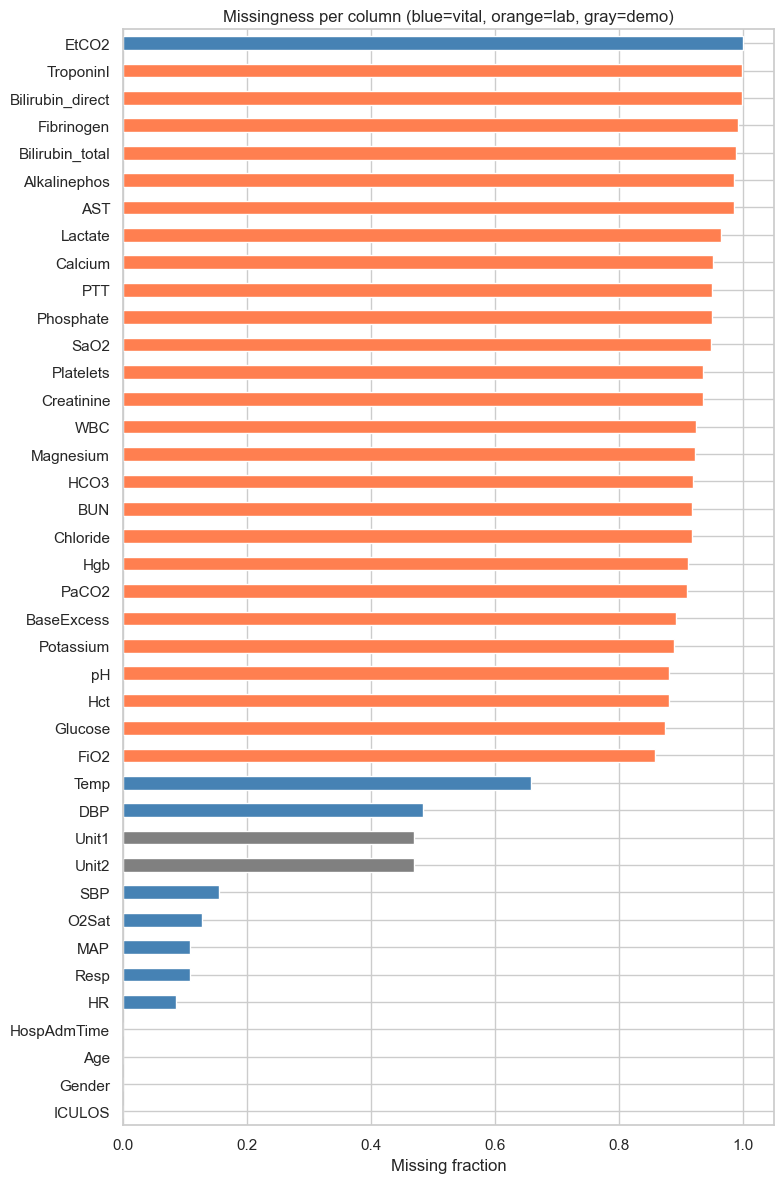

In [4]:
missing_pct = df[VITAL_COLS + LAB_COLS + DEMO_COLS].isna().mean().sort_values()

fig, ax = plt.subplots(figsize=(8, 12))
missing_pct.plot.barh(ax=ax, color=[
    "steelblue" if c in VITAL_COLS else ("coral" if c in LAB_COLS else "gray")
    for c in missing_pct.index
])
ax.set_xlabel("Missing fraction")
ax.set_title("Missingness per column (blue=vital, orange=lab, gray=demo)")
plt.tight_layout()
plt.show()

## 4. Vital distributions: sepsis vs non-sepsis

Hỏi: vital signs khác nhau như thế nào giữa giờ trước sepsis vs giờ bình thường?
Đây là sanity check rằng signal có tồn tại trong data.

C:\Users\ASUS\AppData\Local\Temp\ipykernel_17320\1394909308.py:11: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend(fontsize=8)


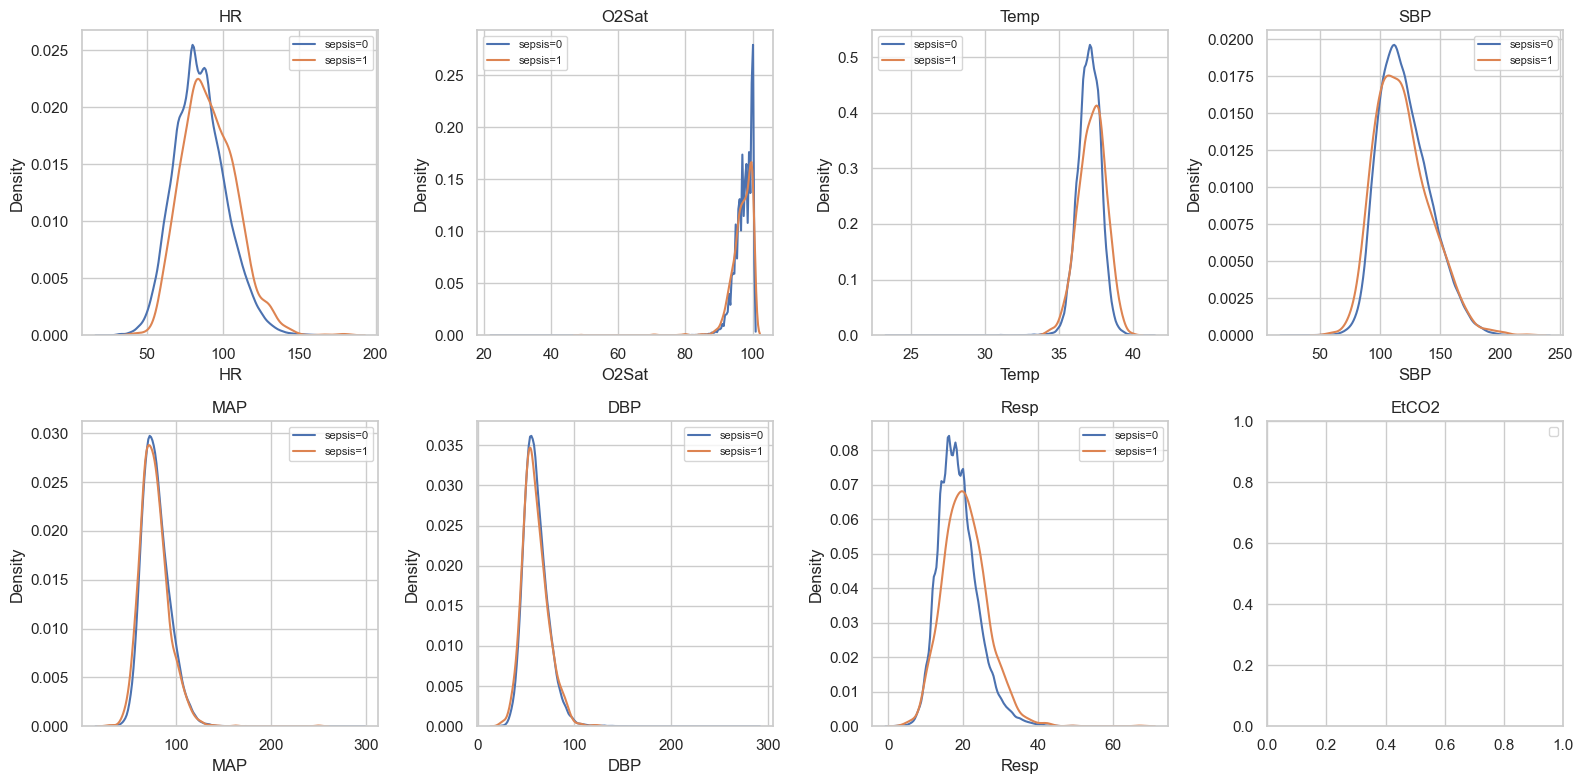

In [5]:
fig, axes = plt.subplots(2, 4, figsize=(16, 8))
for ax, col in zip(axes.flat, VITAL_COLS):
    for label, group in df.groupby(TARGET_COL):
        sns.kdeplot(
            group[col].dropna(),
            ax=ax,
            label=f"sepsis={label}",
            common_norm=False,
        )
    ax.set_title(col)
    ax.legend(fontsize=8)
plt.tight_layout()
plt.show()

## 5. Sepsis onset distribution theo ICULOS

Khi nào sepsis thường xảy ra trong ICU stay? Câu hỏi này quan trọng để hiểu
early-warning có khả thi hay không (nếu mọi case đều xảy ra giờ đầu thì
không kịp dự đoán).

Septic patients: 184
count    184.000000
mean      54.222826
std       61.488009
min        1.000000
25%        8.000000
50%       33.000000
75%       74.500000
max      274.000000
Name: sepsis_label_first_hour, dtype: float64


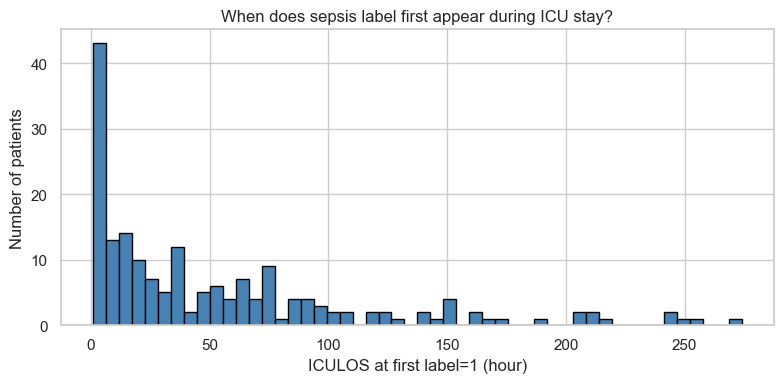

In [6]:
onset_hours = (
    df[df[TARGET_COL] == 1]
    .groupby("patient_id")["ICULOS"]
    .min()
    .rename("sepsis_label_first_hour")
)
print(f"Septic patients: {len(onset_hours)}")
print(onset_hours.describe())

fig, ax = plt.subplots(figsize=(8, 4))
ax.hist(onset_hours, bins=50, color="steelblue", edgecolor="black")
ax.set_xlabel("ICULOS at first label=1 (hour)")
ax.set_ylabel("Number of patients")
ax.set_title("When does sepsis label first appear during ICU stay?")
plt.tight_layout()
plt.show()

## 6. Patient stay length distribution

Để biết window data có đủ lớn cho rolling features hay không.

count    2000.000000
mean       39.903500
std        23.271377
min         8.000000
25%        25.000000
50%        39.000000
75%        48.000000
max       283.000000
Name: ICULOS, dtype: float64


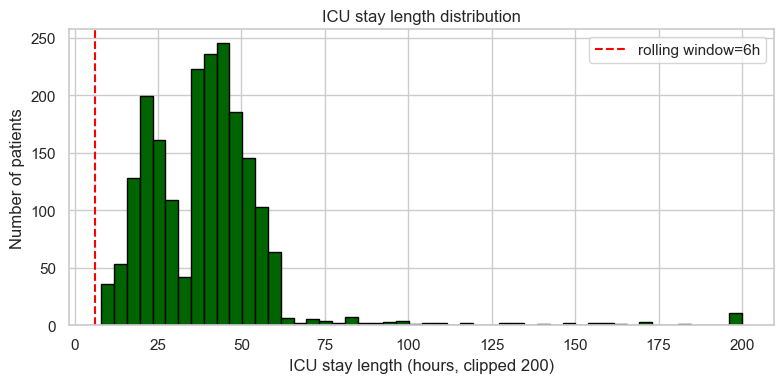

In [7]:
stay_lengths = df.groupby("patient_id")["ICULOS"].max()
print(stay_lengths.describe())

fig, ax = plt.subplots(figsize=(8, 4))
ax.hist(stay_lengths.clip(upper=200), bins=50, color="darkgreen", edgecolor="black")
ax.axvline(6, color="red", linestyle="--", label="rolling window=6h")
ax.set_xlabel("ICU stay length (hours, clipped 200)")
ax.set_ylabel("Number of patients")
ax.set_title("ICU stay length distribution")
ax.legend()
plt.tight_layout()
plt.show()

## Kết luận EDA (cho báo cáo)

1. **Imbalance ~2%** → bắt buộc dùng `scale_pos_weight` cho XGBoost + đánh giá bằng AUPRC + Utility.
2. **Labs missing rate 70-95%** → forward-fill + missingness flag (informative missingness).
3. **Vitals missing rate 10-30%** → XGBoost xử lý NaN native, không cần impute.
4. **Sepsis onset trải đều** trong ICU stay → window 6h trước onset hợp lý cho early warning.
5. **Stay length median ~30-40h** → đủ dài cho rolling 6h.